In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

!pip install -q tensorflow

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, InceptionV3, EfficientNetB0
from tensorflow.keras.applications import resnet50, inception_v3, efficientnet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

2026-04-15 03:02:53.771744: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776222174.049501      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776222174.128733      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776222174.913511      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776222174.913569      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776222174.913572      55 computation_placer.cc:177] computation placer alr

In [2]:
BASE_DIR = "/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET"

TRAIN_DIR = os.path.join(BASE_DIR, "train/images")
VAL_DIR   = os.path.join(BASE_DIR, "validation/images")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 6

In [4]:
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 1440 images belonging to 6 classes.
Found 360 images belonging to 6 classes.


In [5]:
def build_model(base_model, preprocess_fn):
    base = base_model(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base.trainable = False  # Freeze base model

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=outputs)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [7]:
resnet_model = build_model(ResNet50, resnet50.preprocess_input)

history_resnet = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 180s 4s/step - accuracy: 0.3391 - loss: 1.9950 - val_accuracy: 0.8972 - val_loss: 0.4954
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 164s 4s/step - accuracy: 0.8286 - loss: 0.5216 - val_accuracy: 0.9778 - val_loss: 0.2130
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 163s 4s/step - accuracy: 0.9314 - loss: 0.2564 - val_accuracy: 0.9806 - val_loss: 0.1415
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 172s 4s/step - accuracy: 0.9584 - loss: 0.1703 - val_accuracy: 0.9833 - val_loss: 0.1138
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 161s 4s/step - accuracy: 0.9765 - loss: 0.1233 - val_accuracy: 0.9833 - val_loss: 0.0916
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 166s 4s/step - accuracy: 0.9775 - loss: 0.0886 - val_accuracy: 0.9778 - val_loss: 0.0883
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 172s 4s/step - accuracy: 0.9808 - loss: 0.0780 - val_accuracy: 0.9806 - val_loss: 0.0848
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 163s 4s/step - accuracy: 0.9894 - loss: 0.0566 - val_accuracy: 0.9889 - v

In [8]:
# Change preprocessing
train_generator.preprocessing_function = inception_v3.preprocess_input
val_generator.preprocessing_function = inception_v3.preprocess_input

inception_model = build_model(InceptionV3, inception_v3.preprocess_input)

history_inception = inception_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 123s 3s/step - accuracy: 0.2474 - loss: 14.2164 - val_accuracy: 0.4778 - val_loss: 6.3667
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.4909 - loss: 6.5932 - val_accuracy: 0.5611 - val_loss: 2.7242
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.5392 - loss: 3.8034 - val_accuracy: 0.5306 - val_loss: 2.1823
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.5802 - loss: 2.3010 - val_accuracy: 0.6444 - val_loss: 1.2683
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.6196 - loss: 1.6762 - val_accuracy: 0.6583 - val_loss: 1.0714
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 131s 3s/step - accuracy: 0.6196 - loss: 1.2542 - val_accuracy: 0.6583 - val_loss: 1.0002
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.6502 - loss: 1.0613 - val_accuracy: 0.6667 - val_loss: 0.9087
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accura

In [9]:
train_generator.preprocessing_function = efficientnet.preprocess_input
val_generator.preprocessing_function = efficientnet.preprocess_input

efficient_model = build_model(EfficientNetB0, efficientnet.preprocess_input)

history_efficient = efficient_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.2776 - loss: 1.7129 - val_accuracy: 0.5472 - val_loss: 1.5112
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.6914 - loss: 1.0883 - val_accuracy: 0.6694 - val_loss: 1.1891
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.8036 - loss: 0.7566 - val_accuracy: 0.6889 - val_loss: 1.0161
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.8319 - loss: 0.6263 - val_accuracy: 0.7222 - val_loss: 0.8571
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.8779 - loss: 0.5178 - val_accuracy: 0.7389 - val_loss: 0.7935
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.8711 - loss: 0.4398 - val_accuracy: 0.7528 - val_loss: 0.6954
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.8847 - loss: 0.4259 - val_accuracy: 0.7583 - val_loss: 0.6530
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.89

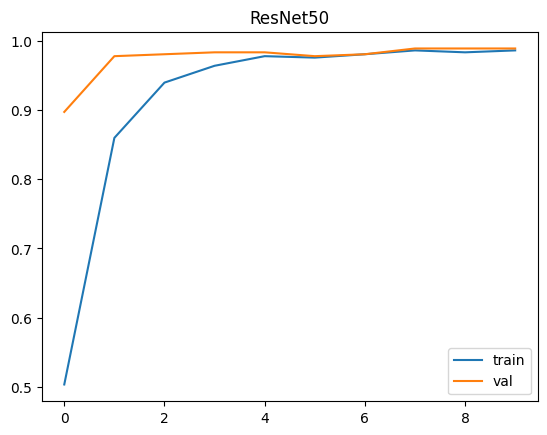

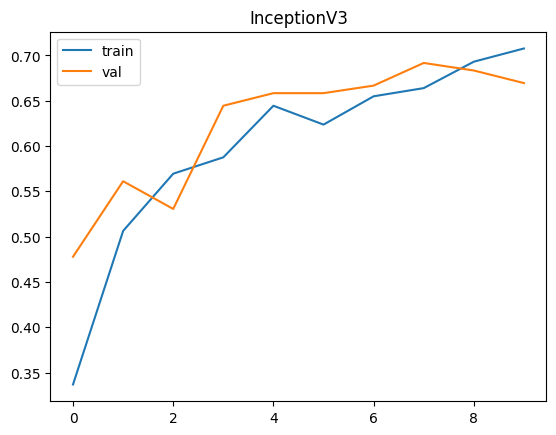

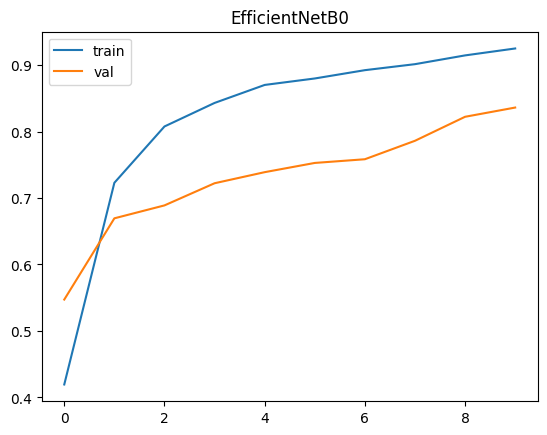

In [10]:
def plot_history(history, title):
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title(title)
    plt.legend()
    plt.show()

plot_history(history_resnet, "ResNet50")
plot_history(history_inception, "InceptionV3")
plot_history(history_efficient, "EfficientNetB0")

In [11]:
def fine_tune(model):
    for layer in model.layers[-30:]:
        layer.trainable = True

    model.compile(
        optimizer=Adam(1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

resnet_model = fine_tune(resnet_model)

resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 224s 5s/step - accuracy: 0.9133 - loss: 0.2646 - val_accuracy: 0.9889 - val_loss: 0.0446
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 258s 5s/step - accuracy: 0.9893 - loss: 0.0794 - val_accuracy: 0.9917 - val_loss: 0.0367
Epoch 3/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 207s 5s/step - accuracy: 0.9921 - loss: 0.0471 - val_accuracy: 0.9944 - val_loss: 0.0308
Epoch 4/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 219s 5s/step - accuracy: 0.9934 - loss: 0.0385 - val_accuracy: 0.9944 - val_loss: 0.0265
Epoch 5/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 208s 5s/step - accuracy: 0.9914 - loss: 0.0371 - val_accuracy: 0.9944 - val_loss: 0.0221
